# Notebook 1 — Data Exploration & Quality

Loads, inspects, and visualises the hedge fund AUM / headcount dataset.

**Data files (in `../data/`):**
- `insample_funds.csv` — 15 in-sample funds, 92 observations (2005–2025)
- `oos_funds.csv`      — 26 out-of-sample funds, 119 observations
- `strategy_metadata.csv` — colour / marker map per strategy code

**Sources:** SEC Form ADV Item 5.B, Man Group Annual Reports (audited),
Bloomberg Intelligence, Pensions & Investments AUM rankings, Hedgeweek.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────────────
IS   = pd.read_csv('../data/insample_funds.csv')
OOS  = pd.read_csv('../data/oos_funds.csv')
META = pd.read_csv('../data/strategy_metadata.csv', index_col='strategy_code')

COLORS  = META['color'].to_dict()
MARKERS = META['marker'].to_dict()
LABELS  = META['strategy_label'].to_dict()

print(f"In-sample   : {len(IS):>4} obs  |  {IS['fund'].nunique():>2} funds")
print(f"Out-of-sample: {len(OOS):>3} obs  |  {OOS['fund'].nunique():>2} funds")


In-sample   :   92 obs  |  15 funds
Out-of-sample: 117 obs  |  27 funds


In [2]:
# ── Per-fund summary table ────────────────────────────────────────────────
def fund_summary(df, label):
    g = df.groupby(['fund','strategy'], sort=False)
    s = g.apply(lambda x: pd.Series({
        'n_obs'   : len(x),
        'yr_range': f"{x['year'].min()}–{x['year'].max()}",
        'aum_min' : x['aum_bn'].min(),
        'aum_max' : x['aum_bn'].max(),
        'hc_min'  : int(x['headcount'].min()),
        'hc_max'  : int(x['headcount'].max()),
        'audited' : any(x['audited']),
    })).reset_index()
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    print(s.to_string(index=False))

fund_summary(IS,  "IN-SAMPLE  (15 funds)")
fund_summary(OOS, "OUT-OF-SAMPLE  (26 funds)")



IN-SAMPLE  (15 funds)
                    fund strategy  n_obs  yr_range  aum_min  aum_max  hc_min  hc_max  audited
               D.E. Shaw        Q     10 2006–2024      6.0     70.0    1200    2600    False
Renaissance Technologies        Q      6 2005–2024      5.0     60.0     200     350    False
               Two Sigma        Q      8 2010–2024      3.0     66.0     200    2000    False
             AQR Capital        Q      6 2009–2023     33.0    226.0     600    1400    False
               Man Group        Q      8 2010–2024     39.0    175.0    1209    1850     True
                 Citadel        P     10 2006–2024     11.0     63.0     900    3100    False
   Millennium Management        P      9 2010–2025     17.0     83.0    1600    6000    False
                 Point72        P      4 2018–2024     14.0     35.0    1200    2200    False
                Balyasny        P      6 2014–2025      4.0     25.0     300    2200    False
             ExodusPoint        P    

## 1.1  Raw AUM and headcount distributions

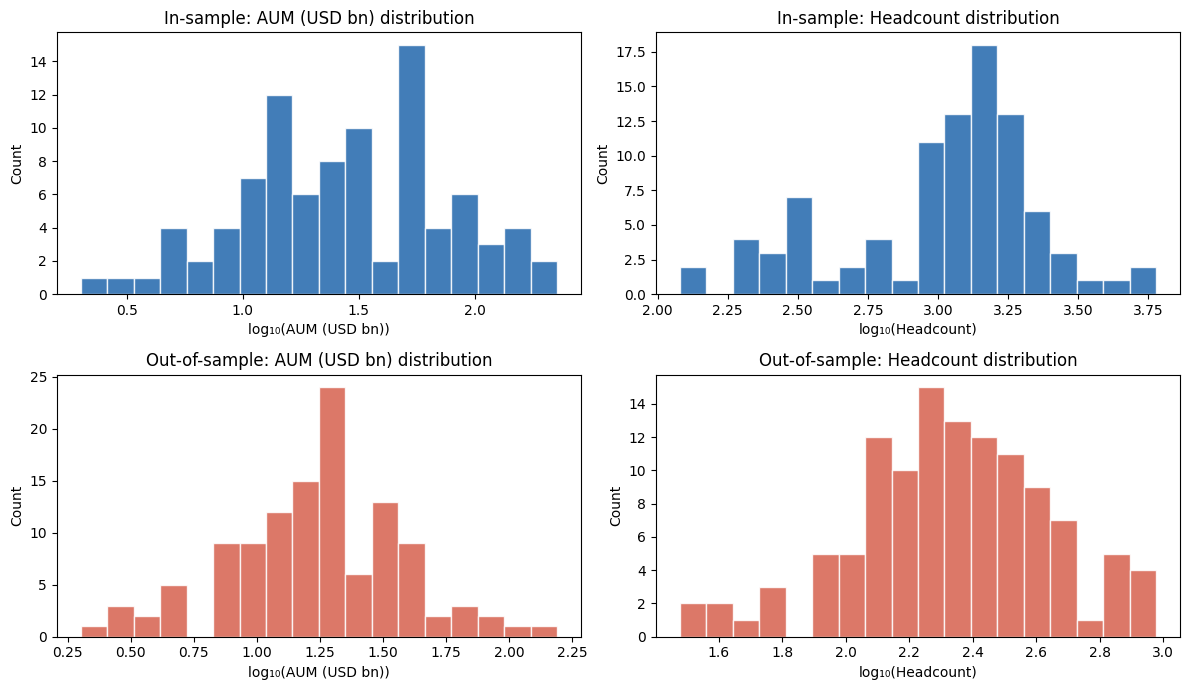

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row, (df, tag) in enumerate([(IS, 'In-sample'), (OOS, 'Out-of-sample')]):
    for col, (col_name, xlabel) in enumerate([
            ('aum_bn',    'AUM (USD bn)'),
            ('headcount', 'Headcount')]):
        ax = axes[row, col]
        ax.hist(np.log10(df[col_name]), bins=18,
                color='#2166ac' if row==0 else '#d6604d',
                edgecolor='white', alpha=0.85)
        ax.set_xlabel(f'log₁₀({xlabel})')
        ax.set_ylabel('Count')
        ax.set_title(f'{tag}: {xlabel} distribution')

plt.tight_layout()
plt.savefig('../figures/explore_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.2  Log-log scatter — all data points

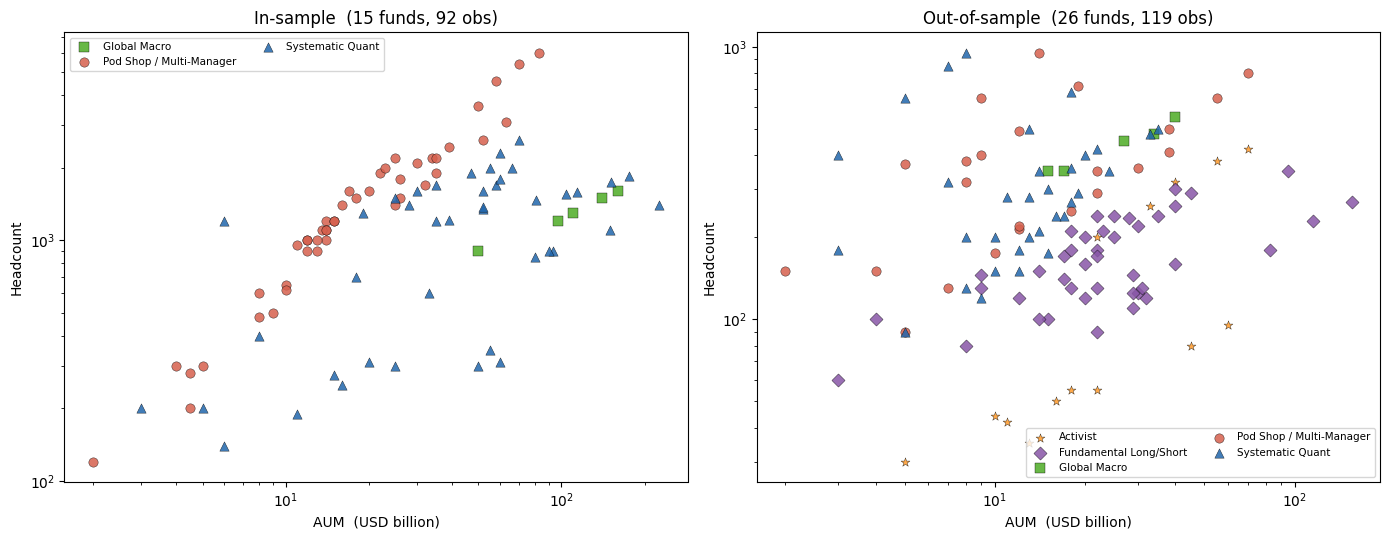

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (df, title) in zip(axes, [(IS, 'In-sample  (15 funds, 92 obs)'),
                                   (OOS,'Out-of-sample  (26 funds, 119 obs)')]):
    for strat, grp in df.groupby('strategy'):
        ax.scatter(grp['aum_bn'], grp['headcount'],
                   color=COLORS.get(strat,'gray'),
                   marker=MARKERS.get(strat,'o'),
                   label=LABELS.get(strat, strat),
                   s=45, alpha=0.85, edgecolors='k', linewidths=0.3)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('AUM  (USD billion)'); ax.set_ylabel('Headcount')
    ax.set_title(title)
    ax.legend(fontsize=7.5, ncol=2)

plt.tight_layout()
plt.savefig('../figures/explore_loglog_raw.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.3  Temporal coverage heatmap (in-sample)

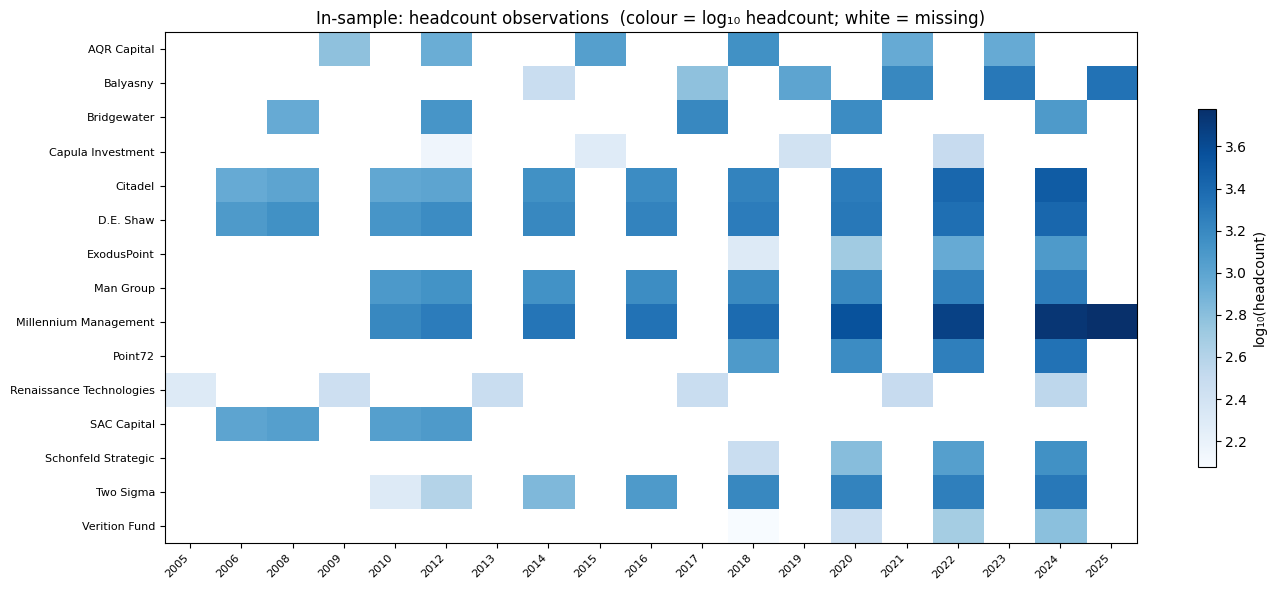

In [5]:
pivot = (IS.pivot_table(values='headcount', index='fund',
                         columns='year', aggfunc='first')
           .reindex(sorted(IS['fund'].unique())))
logpiv = np.log10(pivot.replace(0, np.nan))

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(logpiv.values, aspect='auto', cmap='Blues', origin='upper')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title('In-sample: headcount observations  (colour = log₁₀ headcount; white = missing)')
plt.colorbar(im, ax=ax, label='log₁₀(headcount)', shrink=0.7)
plt.tight_layout()
plt.savefig('../figures/explore_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.4  Capital efficiency — AUM per employee

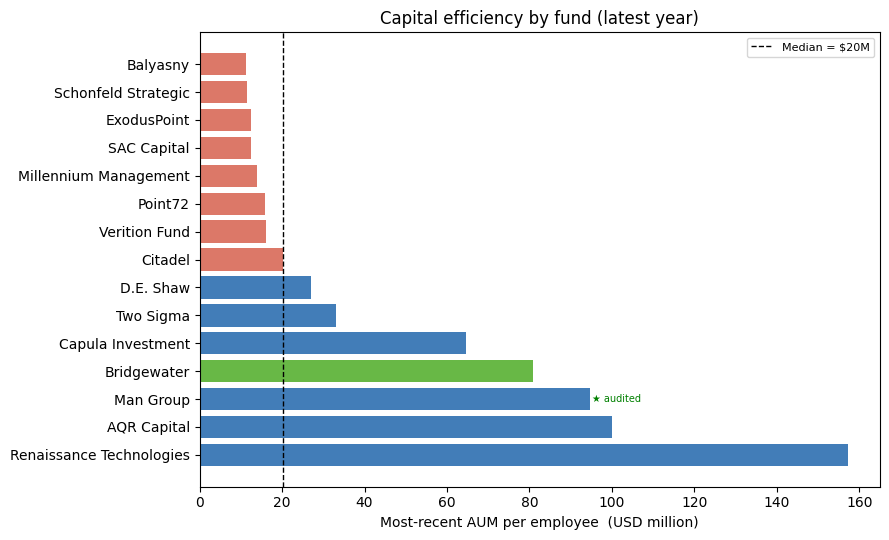


Latest-year efficiency table:
                    fund strategy  aum_bn  headcount  AUM/head (USD M)  audited
Renaissance Technologies        Q    55.0        350        157.142857    False
             AQR Capital        Q    90.0        900        100.000000    False
               Man Group        Q   175.0       1850         94.594595     True
             Bridgewater        M    97.0       1200         80.833333    False
       Capula Investment        Q    20.0        310         64.516129    False
               Two Sigma        Q    66.0       2000         33.000000    False
               D.E. Shaw        Q    70.0       2600         26.923077    False
                 Citadel        P    63.0       3100         20.322581    False
           Verition Fund        P    10.0        620         16.129032    False
                 Point72        P    35.0       2200         15.909091    False
   Millennium Management        P    83.0       6000         13.833333    False
         

In [6]:
IS['aum_per_head_m'] = IS['aum_bn'] * 1000 / IS['headcount']   # USD M / employee

latest = (IS.sort_values('year')
            .groupby('fund').last()
            .reset_index()
            [['fund','strategy','aum_bn','headcount','aum_per_head_m','audited']])
latest = latest.sort_values('aum_per_head_m', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
bar_colors = [COLORS.get(s, 'gray') for s in latest['strategy']]
bars = ax.barh(latest['fund'], latest['aum_per_head_m'],
               color=bar_colors, alpha=0.85)
# Star audited bars
for bar, aud in zip(bars, latest['audited']):
    if aud:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                '★ audited', va='center', fontsize=7, color='green')

med = latest['aum_per_head_m'].median()
ax.axvline(med, color='k', ls='--', lw=1, label=f'Median = ${med:.0f}M')
ax.set_xlabel('Most-recent AUM per employee  (USD million)')
ax.set_title('Capital efficiency by fund (latest year)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/explore_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLatest-year efficiency table:")
print(latest[['fund','strategy','aum_bn','headcount','aum_per_head_m','audited']]
      .rename(columns={'aum_per_head_m':'AUM/head (USD M)'})
      .to_string(index=False))


## 1.5  Measurement uncertainty audit

In [7]:
print("Audited observations (Man Group Annual Reports — < 2% uncertainty):")
print(IS[IS['audited']][['fund','year','aum_bn','headcount']].to_string(index=False))
print(f"\nNon-audited observations: {(~IS['audited']).sum()}  (assumed ±15% headcount uncertainty)")
print("\nSource breakdown:")
print(IS['source'].value_counts().to_string())


Audited observations (Man Group Annual Reports — < 2% uncertainty):
     fund  year  aum_bn  headcount
Man Group  2010    39.0       1209
Man Group  2012    52.0       1347
Man Group  2014    52.0       1373
Man Group  2016    80.8       1473
Man Group  2018   104.0       1558
Man Group  2020   113.5       1584
Man Group  2022   151.7       1741
Man Group  2024   175.0       1850

Non-audited observations: 84  (assumed ±15% headcount uncertainty)

Source breakdown:
source
SEC ADV                    62
SEC ADV / Bloomberg        14
Man Group Annual Report     8
SEC ADV / P&I               5
SEC ADV / Press             1
Press / Hedgeweek           1
Press                       1
